# Test world-coordinate to pixel transformation

This notebook applies the environment's full domain randomization, renders the randomized MuJoCo scene at the camera's native resolution, and calls `world_to_pixel()` for every configured food object. Active objects are marked and labeled in the saved PNG, which keeps the exact native pixel dimensions and aspect ratio.

In [183]:
from pathlib import Path
import sys

import mujoco
from PIL import Image, ImageDraw
from IPython.display import display

environment_dir = Path.cwd()
if not (environment_dir / "xml_models" / "world.xml").exists():
    environment_dir = Path.cwd() / "CODE" / "Enviornment"

if not (environment_dir / "xml_models" / "world.xml").exists():
    raise FileNotFoundError("Run this notebook from the repository root or CODE/Enviornment")

sys.path.insert(0, str(environment_dir))

from enviornment import Enviornment
from enviornment_randomizer import Enviornment_Randomizer
from randomization_constants import Randomization_Constants

In [184]:
constants = Randomization_Constants()
max_scene_attempts = 10

# Some random size/count combinations cannot fit on the plate. Start from
# a fresh model and sample again when the position randomizer reports that.
for scene_attempt in range(1, max_scene_attempts + 1):
    env = Enviornment(
        xml_file=str(environment_dir / "xml_models" / "world.xml"),
        Enviornment_Randomizer=Enviornment_Randomizer(),
        Randomization_Constants=constants,
        checking_height=0.01,
    )
    try:
        # Apply size, rotation, object-count, position, color, camera,
        # lighting, and camera-rotation randomization.
        env.new_scene()
        print(f"Domain-randomized scene created on attempt {scene_attempt}")
        break
    except RuntimeError as error:
        if "without overlap" not in str(error) or scene_attempt == max_scene_attempts:
            raise
        print(f"Scene attempt {scene_attempt} was unplaceable; sampling again")

mujoco.mj_forward(env.model, env.data)
camera_id = env.model.camera(constants.camera_name).id
width, height = map(int, env.model.cam_resolution[camera_id])

print(f"Camera: {constants.camera_name}")
print(f"Native resolution: {width} x {height} pixels")
print(f"Aspect ratio: {width / height:.6f}:1")

Scene attempt 1 was unplaceable; sampling again
Scene attempt 2 was unplaceable; sampling again
Domain-randomized scene created on attempt 3
Camera: emeet_c960_camera
Native resolution: 1920 x 1080 pixels
Aspect ratio: 1.777778:1


In [185]:
projection_results = []
active_height_threshold = (
    constants.in_scene_z_coordinate + constants.out_of_scene_z_coordinate
) / 2.0

for body_name in constants.all_food_body_names:
    body_id = env.model.body(body_name).id
    body_x, body_y, body_z = map(float, env.data.xpos[body_id])
    is_active = body_z >= active_height_threshold

    # Call both transformation methods for every configured food object,
    # including objects that domain randomization moved out of the scene.
    surface_z = env.find_z_at_xy(body_x, body_y)
    pixel_x, pixel_y = env.world_to_pixel(body_x, body_y)
    ray_hit = surface_z != -1
    in_image = (
        (pixel_x, pixel_y) != (-1.0, -1.0)
        and 0 <= pixel_x < width
        and 0 <= pixel_y < height
    )

    projection_results.append({
        "body_name": body_name,
        "world_xyz": (body_x, body_y, body_z),
        "surface_z": surface_z,
        "pixel": (pixel_x, pixel_y),
        "is_active": is_active,
        "ray_hit": ray_hit,
        "in_image": in_image,
    })

print(f"{'Body':28} {'State':9} {'World XYZ':34} {'Pixel (x, y)'}")
print("-" * 100)
for result in projection_results:
    state = "active" if result["is_active"] else "hidden"
    x, y, z = result["world_xyz"]
    px, py = result["pixel"]
    print(
        f"{result['body_name']:28} {state:9} "
        f"({x: .4f}, {y: .4f}, {z: .4f})       "
        f"({px: .2f}, {py: .2f})"
    )

active_results = [result for result in projection_results if result["is_active"]]
assert active_results, "Domain randomization should keep at least one active object"
for result in active_results:
    assert result["ray_hit"], f"Ray missed active object {result['body_name']}"
    assert result["in_image"], f"Active object projected outside image: {result['body_name']}"

Body                         State     World XYZ                          Pixel (x, y)
----------------------------------------------------------------------------------------------------
full_slice_instance          hidden    (-0.1200, -0.0700, -0.1800)       (-1.00, -1.00)
deformed_slice_instance      active    ( 0.0247, -0.0159,  0.1800)       ( 992.43,  593.96)
rod_instance                 active    ( 0.0376,  0.0353,  0.1800)       ( 1047.80,  342.86)
block_instance               active    (-0.0385,  0.0054,  0.1800)       ( 672.89,  498.21)
full_slice_instance_2        hidden    (-0.1200, -0.0700, -0.1800)       (-1.00, -1.00)
deformed_slice_instance_2    hidden    ( 0.0200, -0.0700, -0.1800)       (-1.00, -1.00)
rod_instance_2               active    (-0.0026, -0.0571,  0.1800)       ( 866.21,  796.79)
block_instance_2             hidden    ( 0.1000,  0.0600, -0.1800)       (-1.00, -1.00)


Saved: /Users/aadibhatia/self-feeder-env/CODE/Enviornment/testing_cordinate_transformation_output.png
Saved image dimensions: 1920 x 1080 pixels


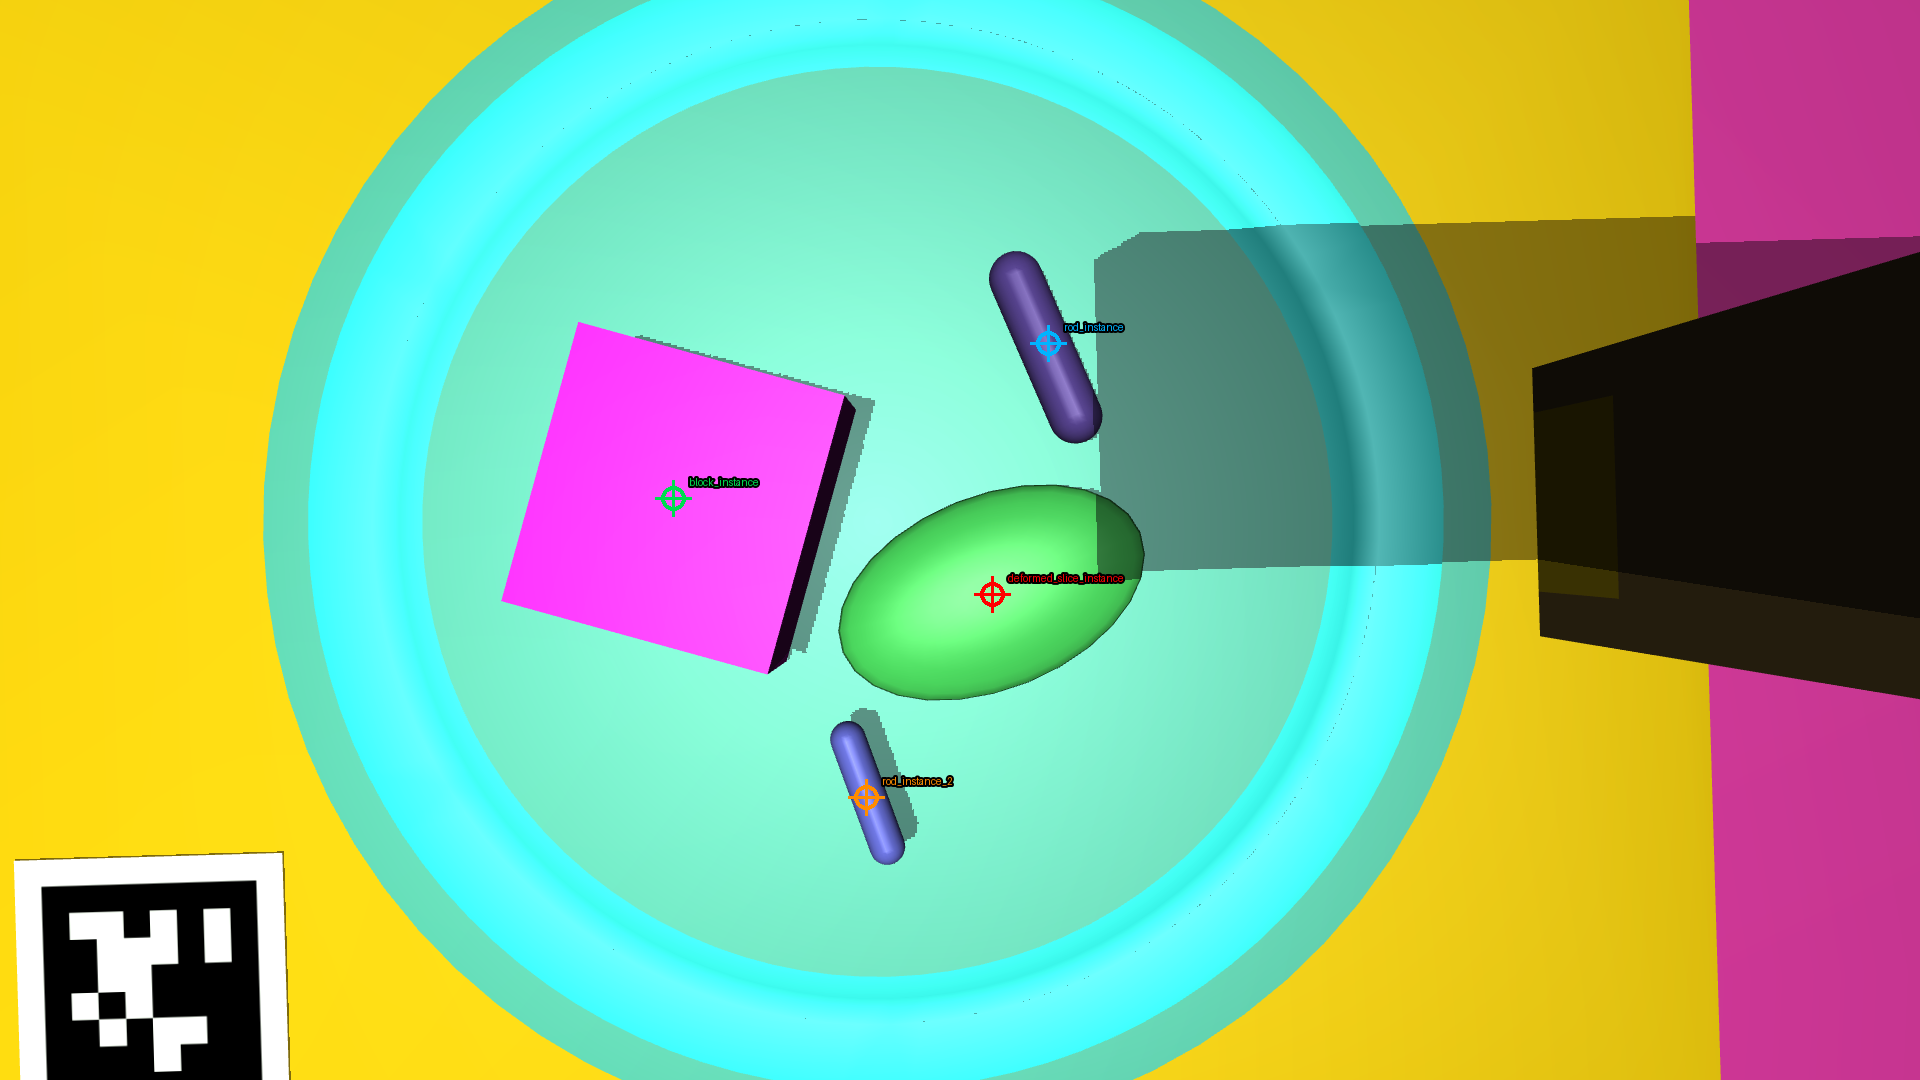

In [186]:
renderer = mujoco.Renderer(env.model, width=width, height=height)
try:
    renderer.update_scene(env.data, camera=camera_id)
    rgb = renderer.render().copy()
finally:
    renderer.close()

marked_image = Image.fromarray(rgb)
draw = ImageDraw.Draw(marked_image)
marker_colors = [
    (255, 0, 0),
    (0, 180, 255),
    (0, 220, 80),
    (255, 140, 0),
    (200, 0, 255),
    (255, 255, 0),
    (0, 255, 255),
    (255, 80, 160),
]
marker_radius = 12

for index, result in enumerate(active_results):
    pixel_x, pixel_y = result["pixel"]
    pixel_column = round(pixel_x)
    pixel_row = round(pixel_y)
    color = marker_colors[index % len(marker_colors)]

    draw.ellipse(
        (
            pixel_column - marker_radius,
            pixel_row - marker_radius,
            pixel_column + marker_radius,
            pixel_row + marker_radius,
        ),
        outline=color,
        width=4,
    )
    draw.line(
        (pixel_column - 18, pixel_row, pixel_column + 18, pixel_row),
        fill=color,
        width=3,
    )
    draw.line(
        (pixel_column, pixel_row - 18, pixel_column, pixel_row + 18),
        fill=color,
        width=3,
    )
    draw.text(
        (pixel_column + 16, pixel_row - 22),
        result["body_name"],
        fill=color,
        stroke_width=2,
        stroke_fill=(0, 0, 0),
    )

output_path = environment_dir / "testing_cordinate_transformation_output.png"
marked_image.save(output_path)

assert marked_image.size == (width, height)
print(f"Saved: {output_path}")
print(f"Saved image dimensions: {marked_image.width} x {marked_image.height} pixels")
display(marked_image)

Preview dimensions: 256 x 144 pixels


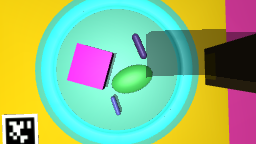

In [187]:
# Render the same randomized scene directly at 256 x 144 pixels.
preview_width, preview_height = 256, 144
preview_renderer = mujoco.Renderer(
    env.model,
    width=preview_width,
    height=preview_height,
)
try:
    preview_renderer.update_scene(env.data, camera=camera_id)
    preview_rgb = preview_renderer.render().copy()
finally:
    preview_renderer.close()

preview_image = Image.fromarray(preview_rgb)
assert preview_image.size == (256, 144)
print(f"Preview dimensions: {preview_image.width} x {preview_image.height} pixels")
display(preview_image)

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from model_constants import Model_Constants

# Attach the model-output configuration used by create_heatmap().
env.Model_Constants = Model_Constants()

# world_to_pixel() returns native-camera coordinates (1920 x 1080).
# Convert them to the model/heatmap coordinate system (256 x 144).
scale_x = env.Model_Constants.output_x_dim / width
scale_y = env.Model_Constants.output_y_dim / height
object_centers_yx = np.array([
    [result["pixel"][1] * scale_y, result["pixel"][0] * scale_x]
    for result in active_results
    if result["in_image"]
], dtype=float)

heatmap = env.create_heatmap(
    sigma=env.Model_Constants.sigma,
    object_centers=object_centers_yx,
)

expected_shape = (
    env.Model_Constants.output_y_dim,
    env.Model_Constants.output_x_dim,
)
assert heatmap.shape == expected_shape
assert np.isfinite(heatmap).all()
assert 0.0 <= heatmap.min() <= heatmap.max() <= env.Model_Constants.max_reward

print(f"Heatmap shape: {heatmap.shape}")
print(f"Object centers in (row, column) format:\n{object_centers_yx}")
print(f"Heatmap value range: {heatmap.min():.6f} to {heatmap.max():.6f}")

Heatmap shape: (144, 256)
Object centers in (row, column) format:
[[ 79.19471891 132.32464428]
 [ 45.71402827 139.70708433]
 [ 66.4282571   89.71807293]
 [106.23923914 115.49446164]]
Heatmap value range: 0.000000 to 0.995532


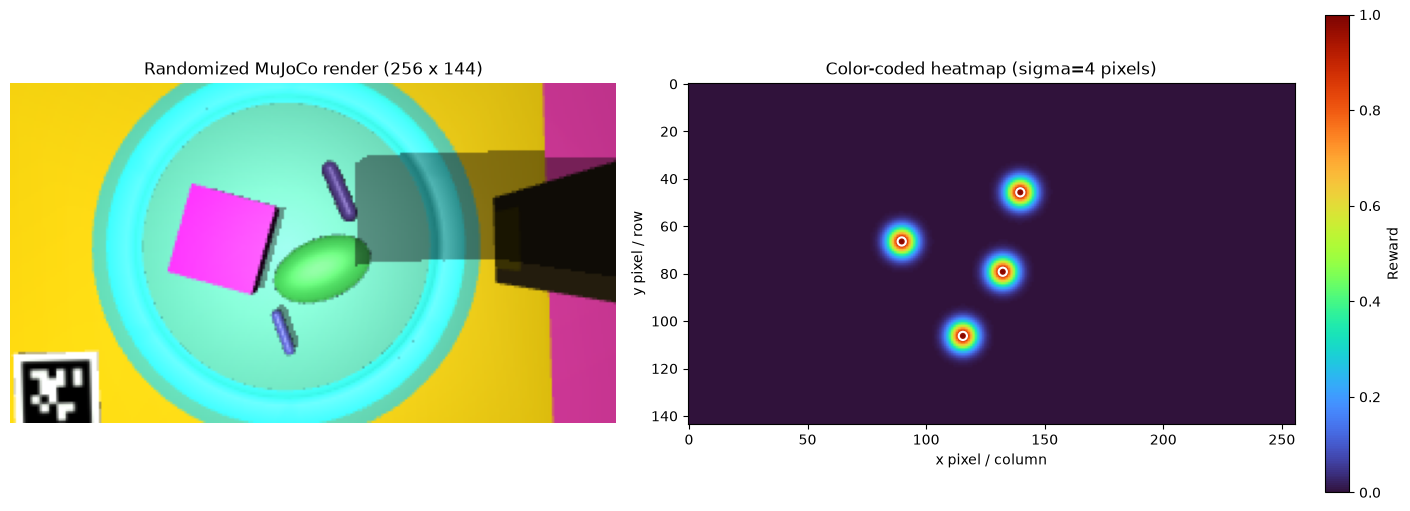

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].imshow(preview_image)
axes[0].set_title("Randomized MuJoCo render (256 x 144)")
axes[0].set_xlim(0, env.Model_Constants.output_x_dim)
axes[0].set_ylim(env.Model_Constants.output_y_dim, 0)
axes[0].axis("off")

heatmap_plot = axes[1].imshow(
    heatmap,
    cmap="turbo",
    vmin=0.0,
    vmax=env.Model_Constants.max_reward,
    origin="upper",
)
if len(object_centers_yx):
    axes[1].scatter(
        object_centers_yx[:, 1],
        object_centers_yx[:, 0],
        s=35,
        facecolors="none",
        edgecolors="white",
        linewidths=1.5,
    )
axes[1].set_title(f"Color-coded heatmap (sigma={env.Model_Constants.sigma} pixels)")
axes[1].set_xlabel("x pixel / column")
axes[1].set_ylabel("y pixel / row")
fig.colorbar(heatmap_plot, ax=axes[1], label="Reward")
plt.show()